# Project- Marketing Campaign Performance Analysis
## Exploratory Data Analysis (EDA)
**Company:** DigitX Media Agency  
**Analyst:** Rajeev Kumar  
**Tools:** Python, Pandas, Matplotlib, Seaborn 

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size']      = 12

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\Marketing Campaigns Analysis\Dataset\Cleaned Dataset\marketing_master.csv") 

print("Dataset loaded successfully!")
print("=" * 40)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nSample (Top 2 rows):")
print(df[['Campaign_ID', 'Date', 'Channel', 'Spend', 'Revenue', 'ROAS', 'ROI_Pct']].head(2))

Dataset loaded successfully!
Rows    : 242,487
Columns : 42

Sample (Top 2 rows):
  Campaign_ID        Date Channel    Spend   Revenue  ROAS  ROI_Pct
0    CMP_0001  2022-11-24     SEO  1221.55  11178.92  9.15   815.14
1    CMP_0001  2022-11-25     SEO   902.44   6339.34  7.02   602.47


In [3]:
df.head()

,Performance_ID,Campaign_ID,Date,Impressions,Clicks,Conversions,Spend,Revenue,CTR,CVR,...,Campaign_Status,Campaign_Duration_Days,Budget_Category,Total_Reach,Avg_Engagement_Rate,Total_Clicks_inf,Total_Conversions_inf,Total_Commission,Total_Revenue_inf,Partner_Count
0,PERF_0000001,CMP_0001,2022-11-24,177258,16972,495,1221.55,11178.92,9.58,2.92,...,Active,310,Medium,68135294,4.756071,602053,67493,650097.68,2901471.38,28
1,PERF_0000002,CMP_0001,2022-11-25,103782,11903,310,902.44,6339.34,11.47,2.61,...,Active,310,Medium,68135294,4.756071,602053,67493,650097.68,2901471.38,28
2,PERF_0000003,CMP_0001,2022-11-26,160018,17696,891,822.83,7996.50,11.06,5.04,...,Active,310,Medium,68135294,4.756071,602053,67493,650097.68,2901471.38,28
3,PERF_0000004,CMP_0001,2022-11-27,112215,7828,398,1256.64,8538.74,6.98,5.10,...,Active,310,Medium,68135294,4.756071,602053,67493,650097.68,2901471.38,28
4,PERF_0000005,CMP_0001,2022-11-28,177284,18175,577,1257.75,10818.46,10.25,3.18,...,Active,310,Medium,68135294,4.756071,602053,67493,650097.68,2901471.38,28


# Chart 1: Overall KPIs

In [4]:
all_col = df.columns.tolist()

In [5]:
print(all_col)

['Performance_ID', 'Campaign_ID', 'Date', 'Impressions', 'Clicks', 'Conversions', 'Spend', 'Revenue', 'CTR', 'CVR', 'CPC', 'CPA', 'ROAS', 'Bounce_Rate', 'Avg_Session_Duration', 'ROI_Pct', 'ROAS_Category', 'CTR_Category', 'Month', 'Quarter', 'Year', 'Revenue_Per_Impression', 'Campaign_Name', 'Channel', 'Campaign_Type', 'Target_Audience', 'Region', 'Start_Date', 'End_Date', 'Total_Budget', 'Product_Category', 'Client_Name', 'Campaign_Status', 'Campaign_Duration_Days', 'Budget_Category', 'Total_Reach', 'Avg_Engagement_Rate', 'Total_Clicks_inf', 'Total_Conversions_inf', 'Total_Commission', 'Total_Revenue_inf', 'Partner_Count']


📌 Overall KPIs:
Total Spend   : ₹474,913,084
Total Revenue : ₹2,822,220,121
Overall ROI   : 494.26%


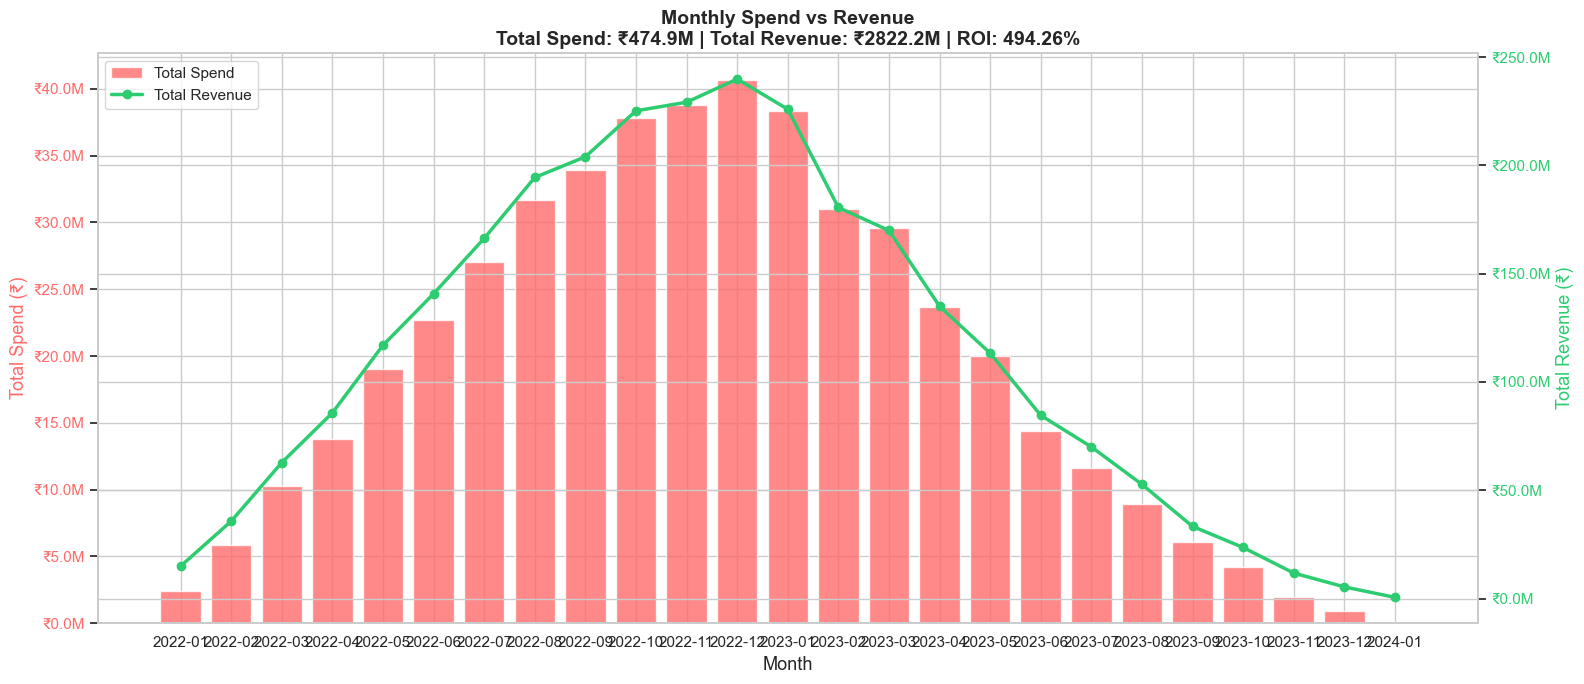

In [6]:
monthly = df.groupby(['Year','Month']).agg(
    Total_spend = ('Spend','sum'),
    Total_revenue = ('Revenue', 'sum')
).reset_index()

monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

monthly = monthly.sort_values('Period').reset_index(drop=True) 

total_spend   = df['Spend'].sum()
total_revenue = df['Revenue'].sum()
total_roi     = ((total_revenue - total_spend) / total_spend * 100).round(2)

print("📌 Overall KPIs:")
print(f"Total Spend   : ₹{total_spend:,.0f}")
print(f"Total Revenue : ₹{total_revenue:,.0f}")
print(f"Overall ROI   : {total_roi}%")

fig, ax1 = plt.subplots(figsize = (16,7)) 

bars = ax1.bar(monthly['Period'], monthly['Total_spend'],
               color='#FF6B6B', alpha=0.8, label='Total Spend')
ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('Total Spend (₹)', color='#FF6B6B', fontsize=13)
ax1.tick_params(axis='y', labelcolor='#FF6B6B')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M')) 

ax2 = ax1.twinx()
ax2.plot(monthly['Period'], monthly['Total_revenue'],
         color='#2ECC71', linewidth=2.5, marker='o', markersize=6, label='Total Revenue')
ax2.set_ylabel('Total Revenue (₹)', color='#2ECC71', fontsize=13)
ax2.tick_params(axis='y', labelcolor='#2ECC71')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.title(f'Monthly Spend vs Revenue\nTotal Spend: ₹{total_spend/1e6:.1f}M | Total Revenue: ₹{total_revenue/1e6:.1f}M | ROI: {total_roi}%',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart1_overall_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 1 — Insight: Monthly Spend vs Revenue (Dual Axis)

**Overall KPIs:**
- Total Spend   : ₹474.9M
- Total Revenue : ₹2822.2M
- Overall ROI   : 494.26% — har ₹1 pe ₹4.94 return

**Key Insights:**
- 2022: Growth phase — campaigns launch hoti rahi, spend aur revenue dono badhte rahe
- Peak Nov-Dec 2022 — Monthly Spend ~₹40M, Monthly Revenue ~₹240M
- 2023: Decline phase — purani campaigns end hoti gayi, nayi add nahi hui
- Revenue line hamesha Spend bars se upar hai — agency consistently profitable hai
- Worst month bhi ROI positive — koi bhi month loss mein nahi gaya

#  Chart 2: Channel wise ROAS 

📌 Channel wise Avg ROAS:
           Channel  Avg_ROAS
0  Email Marketing     11.49
1              SEO      8.49
2        Affiliate      6.47
3       Google Ads      5.25
4         Meta Ads      4.00
5      YouTube Ads      3.25
6       Influencer      2.75

Overall Benchmark ROAS : 5.82


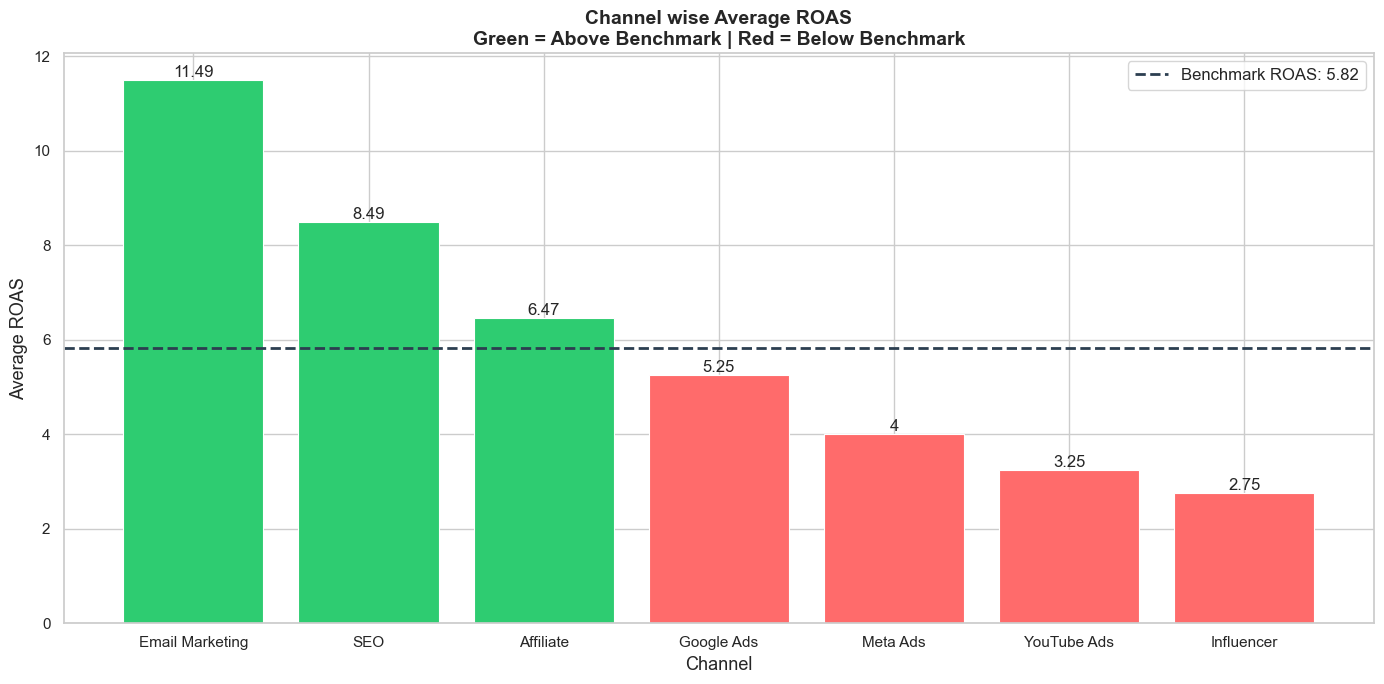

✅ Chart 2 saved!


In [7]:
channel_roas = df.groupby('Channel')['ROAS'].mean().round(2).reset_index()

channel_roas.columns = ['Channel','Avg_ROAS'] 
channel_roas = channel_roas.sort_values('Avg_ROAS', ascending = False).reset_index(drop = True) 


benchmark = df['ROAS'].mean().round(2)
print("📌 Channel wise Avg ROAS:")
print(channel_roas)
print(f"\nOverall Benchmark ROAS : {benchmark}")

fig,ax = plt.subplots(figsize = (14,7)) 

colors = ['#2ECC71' if x >= benchmark else '#FF6B6B' for x in channel_roas['Avg_ROAS']]

bars = ax.bar(channel_roas['Channel'], channel_roas['Avg_ROAS'], 
             color=colors, edgecolor='white', linewidth=0.8)

ax.axhline(y=benchmark, color='#2C3E50', linewidth=2,
           linestyle='--', label=f'Benchmark ROAS: {benchmark}')

ax.bar_label(bars)

ax.set_title('Channel wise Average ROAS\nGreen = Above Benchmark | Red = Below Benchmark',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Channel', fontsize=13)
ax.set_ylabel('Average ROAS', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart2_channel_roas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

### Chart 2 — Insight: Channel wise Average ROAS

**Benchmark ROAS : 5.82** (overall average across all channels)

**Key Insights:**
- Email Marketing is the best performing channel with an average ROAS of 11.49 — nearly 2x the benchmark
- SEO is the second best channel with a ROAS of 8.49 — strong return with no paid media cost
- Affiliate channel just crosses the benchmark at 6.47 — decent but not outstanding
- Google Ads, Meta Ads, YouTube Ads, and Influencer all fall below the benchmark
- Influencer is the worst performing channel with a ROAS of only 2.75 — highest cost, lowest return
- The agency should increase budget allocation toward Email Marketing and SEO
- Influencer marketing budget should be reviewed — it is not generating enough return

# Chart 3: Monthly Trend + Moving Average

📌 Monthly Trend with Moving Average (first 5 rows):
    Period  Total_Spend     Spend_MA3  Total_Revenue   Revenue_MA3
0  2022-01   2398697.81           NaN   1.492916e+07           NaN
1  2022-02   5836027.13           NaN   3.570116e+07           NaN
2  2022-03  10308561.67  6.181096e+06   6.278402e+07  3.780478e+07
3  2022-04  13821152.65  9.988580e+06   8.573871e+07  6.140796e+07
4  2022-05  19016112.04  1.438194e+07   1.169441e+08  8.848893e+07
5  2022-06  22732433.37  1.852323e+07   1.407273e+08  1.144700e+08
6  2022-07  27025432.58  2.292466e+07   1.663039e+08  1.413251e+08


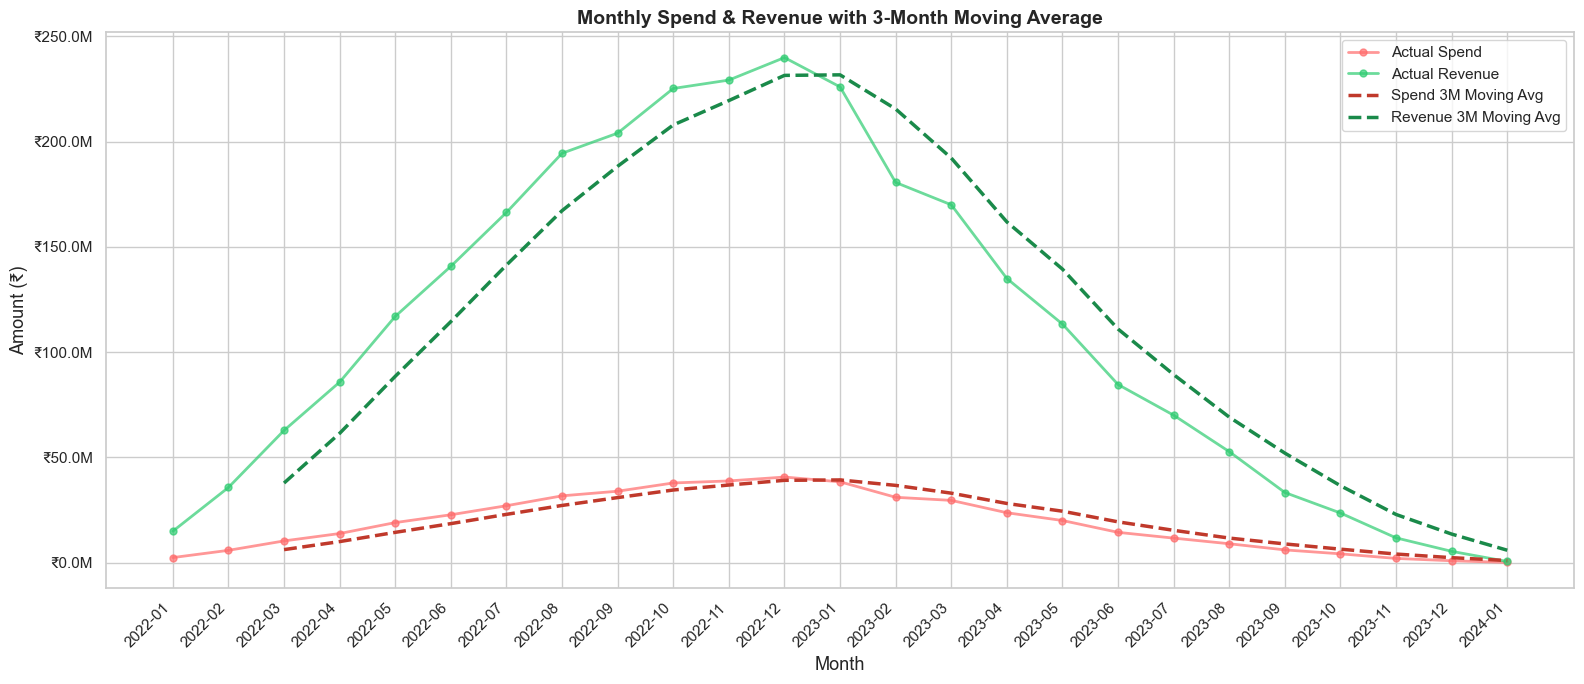

✅ Chart 3 saved!


In [8]:
monthly_trend = df.groupby(['Year','Month']).agg(
    Total_Spend = ('Spend','sum'), 
    Total_Revenue = ('Revenue', 'sum')
).reset_index()

monthly_trend['Period'] = monthly_trend['Year'].astype(str) + '-' + monthly_trend['Month'].astype(str).str.zfill(2)
monthly_trend = monthly_trend.sort_values('Period').reset_index(drop=True)

monthly_trend['Spend_MA3'] = monthly_trend['Total_Spend'].rolling(window=3).mean()
monthly_trend['Revenue_MA3'] = monthly_trend['Total_Revenue'].rolling(window=3).mean()
 
print("📌 Monthly Trend with Moving Average (first 5 rows):")
print(monthly_trend[['Period', 'Total_Spend', 'Spend_MA3', 'Total_Revenue', 'Revenue_MA3']].head(7))



fig,ax = plt.subplots(figsize=(16,7))

ax.plot(monthly_trend['Period'], monthly_trend['Total_Spend'],
        color='#FF6B6B', linewidth=2, marker='o', markersize=5,
        label='Actual Spend', alpha=0.7)

ax.plot(monthly_trend['Period'], monthly_trend['Total_Revenue'],
        color='#2ECC71', linewidth=2, marker='o', markersize=5,
        label='Actual Revenue', alpha=0.7)

# Moving Average lines
ax.plot(monthly_trend['Period'], monthly_trend['Spend_MA3'],
        color='#C0392B', linewidth=2.5, linestyle='--',
        label='Spend 3M Moving Avg')

ax.plot(monthly_trend['Period'], monthly_trend['Revenue_MA3'],
        color='#1A8A4A', linewidth=2.5, linestyle='--',
        label='Revenue 3M Moving Avg')

ax.set_title('Monthly Spend & Revenue with 3-Month Moving Average',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Amount (₹)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart3_monthly_trend_ma.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

### Chart 3 — Insight: Monthly Spend & Revenue with 3-Month Moving Average

**Key Insights:**
- Revenue grew consistently from January 2022 and peaked at around ₹240M in December 2022
- Spend stayed relatively flat between ₹20M-₹40M throughout the year — revenue grew much faster than spend
- After December 2022, both spend and revenue declined steadily through 2023 as campaigns ended
- The 3-month moving average smooths out small ups and downs and confirms the overall trend clearly
- The gap between revenue and spend lines is large throughout — this shows the agency maintained strong returns every single month
- No sudden drops or spikes in the moving average — growth and decline both happened gradually

# Chart 4 — Campaign Type wise CVR

📌 Campaign Type wise Avg CVR:
     Campaign_Type  Avg_CVR
0  Brand Awareness     4.51
1       Conversion     4.51
2       Engagement     4.51
3  Lead Generation     4.51
4      Retargeting     4.50

Overall Benchmark CVR : 4.5%


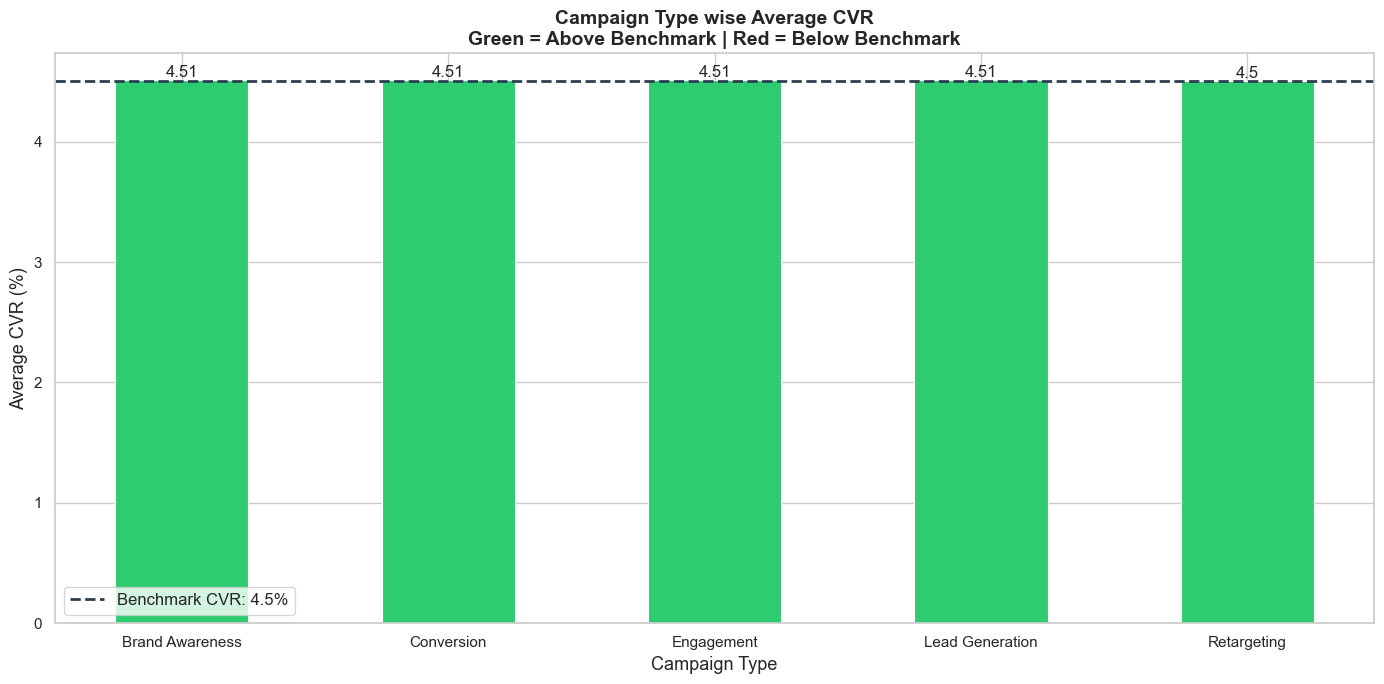

✅ Chart 4 saved!


In [16]:
campaign_cvr = df.groupby('Campaign_Type')['CVR'].mean().round(2).reset_index()
campaign_cvr.columns = ['Campaign_Type', 'Avg_CVR']
campaign_cvr = campaign_cvr.sort_values('Avg_CVR', ascending=False).reset_index(drop=True)
benchmark_cvr = df['CVR'].mean().round(2)

print("📌 Campaign Type wise Avg CVR:")
print(campaign_cvr)
print(f"\nOverall Benchmark CVR : {benchmark_cvr}%")

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2ECC71' if x >= benchmark_cvr else '#FF6B6B' for x in campaign_cvr['Avg_CVR']]

bars = ax.bar(campaign_cvr['Campaign_Type'], campaign_cvr['Avg_CVR'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.5)

# Benchmark line
ax.axhline(y=benchmark_cvr, color='#2C3E50', linewidth=2,
           linestyle='--', label=f'Benchmark CVR: {benchmark_cvr}%')

ax.bar_label(bars)

ax.set_title('Campaign Type wise Average CVR\nGreen = Above Benchmark | Red = Below Benchmark',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Campaign Type', fontsize=13)
ax.set_ylabel('Average CVR (%)', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart4_campaign_type_cvr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

### Chart 4 — Insight: Campaign Type wise Average CVR

**Benchmark CVR : 4.5%**

**Key Insights:**
- All campaign types show almost identical CVR between 4.50% and 4.51%
- This suggests that CVR in this dataset was generated uniformly and is not differentiated by campaign type
- In a real business scenario, Retargeting and Conversion campaigns would typically have higher CVR than Brand Awareness campaigns
- Since all types perform equally, CVR alone cannot be used to recommend one campaign type over another
- Other metrics like ROAS and Revenue should be used to evaluate campaign type performance instead

#  Chart 5: Region wise Revenue

📌 Region wise Revenue:
    Region  Total_Revenue_M  Avg_ROAS  ROI_Pct
0     East           649.56  5.609697   485.61
1    North           634.13  6.160070   533.83
2  Central           575.68  5.553281   486.00
3    South           554.12  5.953975   487.43
4     West           408.72  5.888919   472.65


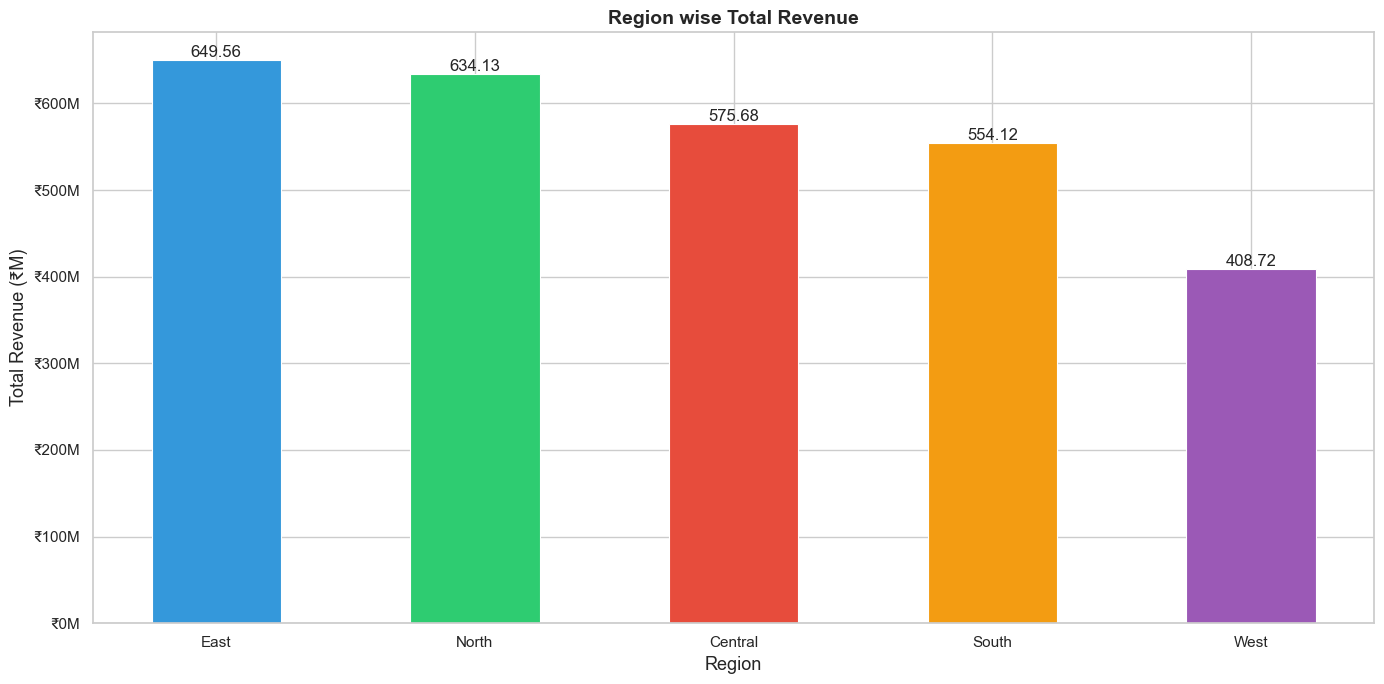

✅ Chart 5 saved!


In [22]:
region_revenue = df.groupby('Region').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Spend   = ('Spend',   'sum'),
    Avg_ROAS      = ('ROAS',    'mean')
).reset_index()

region_revenue['ROI_Pct'] = ((region_revenue['Total_Revenue'] - region_revenue['Total_Spend']) / region_revenue['Total_Spend'] * 100).round(2)
region_revenue['Total_Revenue_M'] = (region_revenue['Total_Revenue'] / 1e6).round(2)
region_revenue = region_revenue.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)


print("📌 Region wise Revenue:")
print(region_revenue[['Region', 'Total_Revenue_M', 'Avg_ROAS', 'ROI_Pct']])

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']

bars = ax.bar(region_revenue['Region'], region_revenue['Total_Revenue_M'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.5)
ax.bar_label(bars)

ax.set_title('Region wise Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Region', fontsize=13)
ax.set_ylabel('Total Revenue (₹M)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}M'))

plt.tight_layout()
plt.savefig('chart5_region_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

### Chart 5 — Insight: Region wise Total Revenue

**Key Insights:**
- East region generated the highest total revenue at ₹649.56M, followed closely by North at ₹634.13M
- West region is the weakest performer with only ₹408.72M in revenue — significantly lower than all other regions
- North region has the highest ROI at 533.83% — it generates the most return per rupee spent even though it ranks second in total revenue
- East leads in revenue but North leads in efficiency — both are strong regions for the agency
- Central and South are mid-performers with similar revenue and ROI numbers
- West region should be investigated further — both revenue and ROI are the lowest across all regions

# Chart 6: Product Category wise ROAS 

📌 Product Category wise Avg ROAS:
    Product_Category  Avg_ROAS
0          Education      6.00
1        Electronics      5.97
2            Fashion      5.94
3   Health & Fitness      5.94
4             Travel      5.89
5      Home & Living      5.81
6   Food & Beverages      5.55
7  Beauty & Skincare      5.39

Overall Benchmark ROAS : 5.82


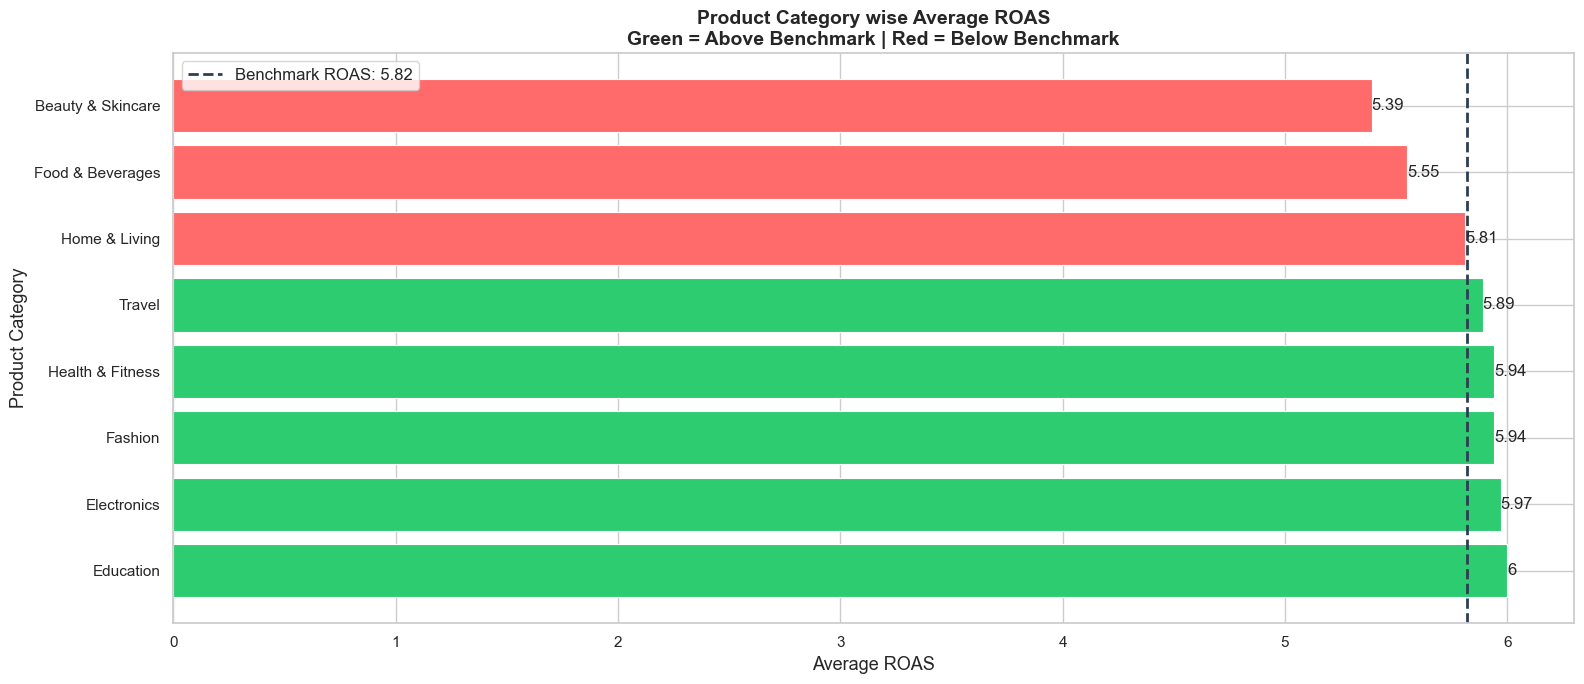

✅ Chart 6 saved!


In [26]:
category_roas = df.groupby('Product_Category').agg(
    Avg_ROAS      = ('ROAS',    'mean'),
    Total_Revenue = ('Revenue', 'sum'),
    Total_Spend   = ('Spend',   'sum')
).reset_index()

category_roas['Avg_ROAS'] = category_roas['Avg_ROAS'].round(2)
category_roas = category_roas.sort_values('Avg_ROAS', ascending=False).reset_index(drop=True)

# Benchmark
benchmark_roas = df['ROAS'].mean().round(2)

print("📌 Product Category wise Avg ROAS:")
print(category_roas[['Product_Category', 'Avg_ROAS']])
print(f"\nOverall Benchmark ROAS : {benchmark_roas}")



fig, ax = plt.subplots(figsize=(16, 7))

colors = ['#2ECC71' if x >= benchmark_roas else '#FF6B6B' for x in category_roas['Avg_ROAS']]

bars = ax.barh(category_roas['Product_Category'], category_roas['Avg_ROAS'],
               color=colors, edgecolor='white', linewidth=0.8)

ax.axvline(x=benchmark_roas, color='#2C3E50', linewidth=2,
           linestyle='--', label=f'Benchmark ROAS: {benchmark_roas}')
ax.bar_label(bars)

ax.set_title('Product Category wise Average ROAS\nGreen = Above Benchmark | Red = Below Benchmark',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average ROAS', fontsize=13)
ax.set_ylabel('Product Category', fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart6_category_roas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

### Chart 6 — Insight: Product Category wise Average ROAS

**Benchmark ROAS : 5.82**

**Key Insights:**
- Education is the top performing product category with an average ROAS of 6.00, followed by Electronics at 5.97
- Beauty & Skincare is the weakest category with a ROAS of 5.39 — the only category noticeably below benchmark
- Food & Beverages also falls below benchmark at 5.55 — both categories need budget reallocation or strategy review
- The overall gap between the best and worst category is very small (6.00 vs 5.39) — all categories are performing at a similar level
- Education, Electronics, Fashion, and Health & Fitness are all above benchmark and delivering strong returns
- Home & Living sits right at the benchmark line — not a concern but worth monitoring

#  Chart 7: Top 10 Campaigns by Revenue

📌 Top 10 Campaigns by Revenue:
                                     Campaign_Name          Channel  \
0   Food & Beverages_Lead Generation_Campaign_0510  Email Marketing   
1      Beauty & Skincare_Retargeting_Campaign_0113  Email Marketing   
2            Fashion_Brand Awareness_Campaign_0102  Email Marketing   
3               Education_Conversion_Campaign_0176  Email Marketing   
4  Beauty & Skincare_Brand Awareness_Campaign_0238  Email Marketing   
5                  Travel_Engagement_Campaign_0365  Email Marketing   
6   Food & Beverages_Brand Awareness_Campaign_0677  Email Marketing   
7          Education_Brand Awareness_Campaign_0262  Email Marketing   
8          Education_Brand Awareness_Campaign_0409  Email Marketing   
9                  Travel_Conversion_Campaign_0743  Email Marketing   

   Total_Revenue_M  Avg_ROAS  
0            29.63     11.78  
1            29.40     11.66  
2            29.05     11.64  
3            28.98     11.52  
4            28.95     11.53  
5

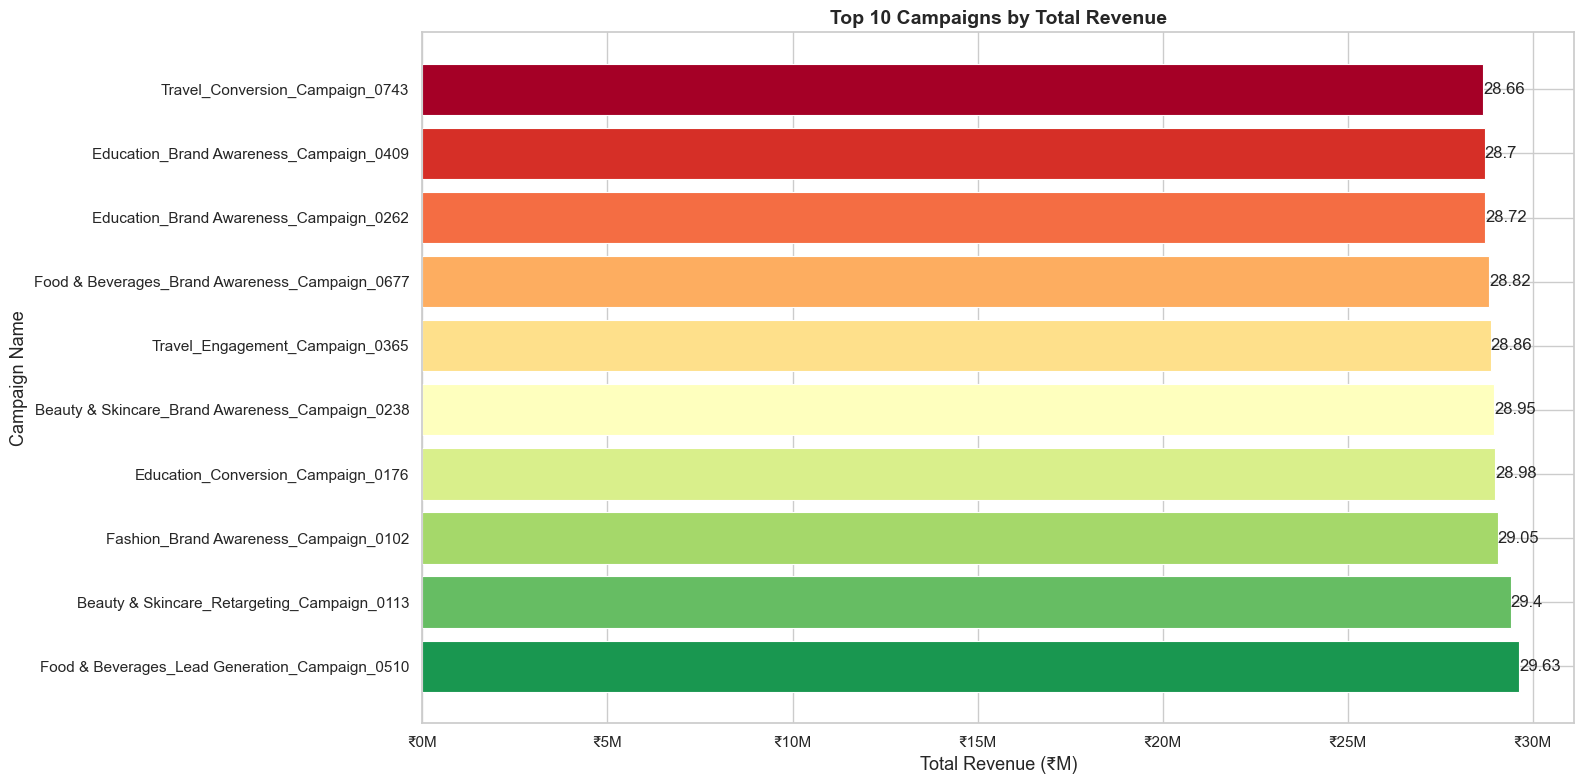

✅ Chart 7 saved!


In [31]:
top10_campaigns = df.groupby(['Campaign_ID', 'Campaign_Name', 'Channel', 'Product_Category']).agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Spend   = ('Spend',   'sum'),
    Avg_ROAS      = ('ROAS',    'mean')
).reset_index()


top10_campaigns['Total_Revenue_M'] = (top10_campaigns['Total_Revenue'] / 1e6).round(2)
top10_campaigns['Avg_ROAS']        = top10_campaigns['Avg_ROAS'].round(2)
top10_campaigns = top10_campaigns.sort_values('Total_Revenue', ascending=False).head(10).reset_index(drop=True)

print("📌 Top 10 Campaigns by Revenue:")
print(top10_campaigns[['Campaign_Name', 'Channel', 'Total_Revenue_M', 'Avg_ROAS']])


fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.RdYlGn([i / len(top10_campaigns) for i in range(len(top10_campaigns))])[::-1]

bars = ax.barh(top10_campaigns['Campaign_Name'], top10_campaigns['Total_Revenue_M'],
               color=colors, edgecolor='white', linewidth=0.8)

ax.bar_label(bars)

ax.set_title('Top 10 Campaigns by Total Revenue',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (₹M)', fontsize=13)
ax.set_ylabel('Campaign Name', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}M'))

plt.tight_layout()
plt.savefig('chart7_top10_campaigns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

### Chart 7 — Insight: Top 10 Campaigns by Total Revenue

**Key Insights:**
- All top 10 campaigns belong to the Email Marketing channel — confirming it as the strongest channel in the agency
- The top campaign — Food & Beverages Lead Generation Campaign 0510 — generated ₹29.63M in revenue with a ROAS of 11.78
- All top 10 campaigns have a ROAS above 11.50 — nearly double the overall benchmark of 5.82
- The revenue gap between rank 1 and rank 10 is very small (₹29.63M vs ₹28.66M) — all top campaigns performed at a similar level
- Top campaigns span multiple product categories — Travel, Education, Fashion, Food & Beverages, Beauty & Skincare — Email Marketing works well across all categories
- This strongly suggests that increasing budget allocation toward Email Marketing campaigns can drive higher revenue across product categories

# Chart 8 — CTR vs CVR Scatter Plot by Channel

📌 Scatter Data Sample:
  Campaign_ID          Channel  Avg_CTR  Avg_CVR  Avg_ROAS
0    CMP_0001              SEO     8.43     4.49      8.52
1    CMP_0002  Email Marketing    25.00     4.51     11.45
2    CMP_0003      YouTube Ads     2.57     4.49      3.25
3    CMP_0004        Affiliate     6.99     4.27      6.46
4    CMP_0005        Affiliate     7.16     4.59      6.54

Total campaigns plotted: 800


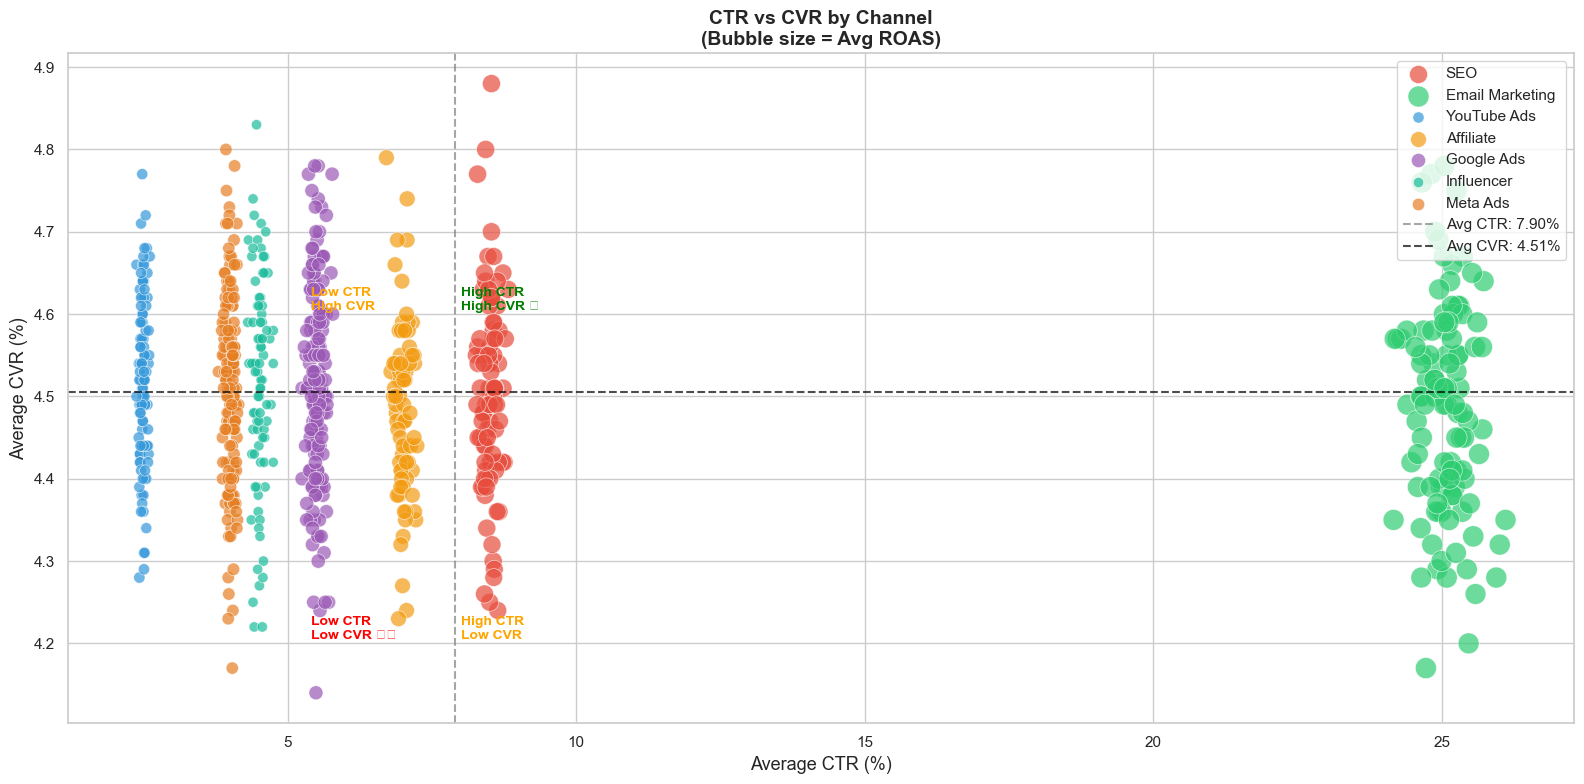

✅ Chart 8 saved!


In [35]:
scatter_data = df.groupby(['Campaign_ID', 'Channel']).agg(
    Avg_CTR = ('CTR', 'mean'),
    Avg_CVR = ('CVR', 'mean'),
    Avg_ROAS = ('ROAS', 'mean')
).reset_index()

scatter_data['Avg_CTR']  = scatter_data['Avg_CTR'].round(2)
scatter_data['Avg_CVR']  = scatter_data['Avg_CVR'].round(2)
scatter_data['Avg_ROAS'] = scatter_data['Avg_ROAS'].round(2)

print("📌 Scatter Data Sample:")
print(scatter_data.head(5))
print(f"\nTotal campaigns plotted: {scatter_data.shape[0]}")


fig, ax = plt.subplots(figsize=(16, 8))

channels = scatter_data['Channel'].unique()
colors   = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22']

for channel, color in zip(channels, colors):
    subset = scatter_data[scatter_data['Channel'] == channel]
    ax.scatter(subset['Avg_CTR'], subset['Avg_CVR'],
               c=color, label=channel, alpha=0.7,
               s=subset['Avg_ROAS'] * 20,
               edgecolors='white', linewidth=0.5)


avg_ctr = scatter_data['Avg_CTR'].mean()
avg_cvr = scatter_data['Avg_CVR'].mean()

ax.axvline(x=avg_ctr, color='gray', linewidth=1.5,
           linestyle='--', alpha=0.7, label=f'Avg CTR: {avg_ctr:.2f}%')
ax.axhline(y=avg_cvr, color='black', linewidth=1.5,
           linestyle='--', alpha=0.7, label=f'Avg CVR: {avg_cvr:.2f}%')


ax.text(avg_ctr + 0.1, avg_cvr + 0.1, 'High CTR\nHigh CVR ⭐',
        fontsize=10, color='green', fontweight='bold')
ax.text(avg_ctr - 2.5, avg_cvr + 0.1, 'Low CTR\nHigh CVR',
        fontsize=10, color='orange', fontweight='bold')
ax.text(avg_ctr + 0.1, avg_cvr - 0.3, 'High CTR\nLow CVR',
        fontsize=10, color='orange', fontweight='bold')
ax.text(avg_ctr - 2.5, avg_cvr - 0.3, 'Low CTR\nLow CVR ⚠️',
        fontsize=10, color='red', fontweight='bold')

ax.set_title('CTR vs CVR by Channel\n(Bubble size = Avg ROAS)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average CTR (%)', fontsize=13)
ax.set_ylabel('Average CVR (%)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('chart8_ctr_cvr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

### Chart 8 — Insight: CTR vs CVR Scatter Plot by Channel

**Avg CTR: 7.90% | Avg CVR: 4.51%**

**Key Insights:**
- Email Marketing stands out completely from all other channels — its CTR ranges from 25% to 26%, far higher than every other channel
- All other channels have a CTR between 2% and 10% — Email Marketing is nearly 3x higher in click-through rate
- Email Marketing dots are the largest on the chart — confirming it has the highest ROAS as well
- SEO campaigns cluster in the High CTR zone (8-10%) — the only non-Email channel to cross the average CTR line
- CVR is similar across all channels (4.2% to 4.9%) — the real differentiator between channels is CTR and ROAS, not CVR
- Influencer, YouTube Ads, and Meta Ads all sit in the Low CTR zone — consistent with their poor ROAS seen in Chart 2

# Chart 9 — Influencer vs Affiliate Comparison

📌 Influencer vs Affiliate Comparison:
      Channel  Avg_ROAS  Avg_CTR  Avg_CVR  Avg_ROI  Total_Revenue_M
0   Affiliate      6.47     7.01     4.48   547.32           256.69
1  Influencer      2.75     4.51     4.52   174.84           152.94

📌 Melted Data:
      Channel    Metric   Value
0   Affiliate  Avg_ROAS    6.47
1  Influencer  Avg_ROAS    2.75
2   Affiliate   Avg_CTR    7.01
3  Influencer   Avg_CTR    4.51
4   Affiliate   Avg_CVR    4.48
5  Influencer   Avg_CVR    4.52
6   Affiliate   Avg_ROI  547.32
7  Influencer   Avg_ROI  174.84


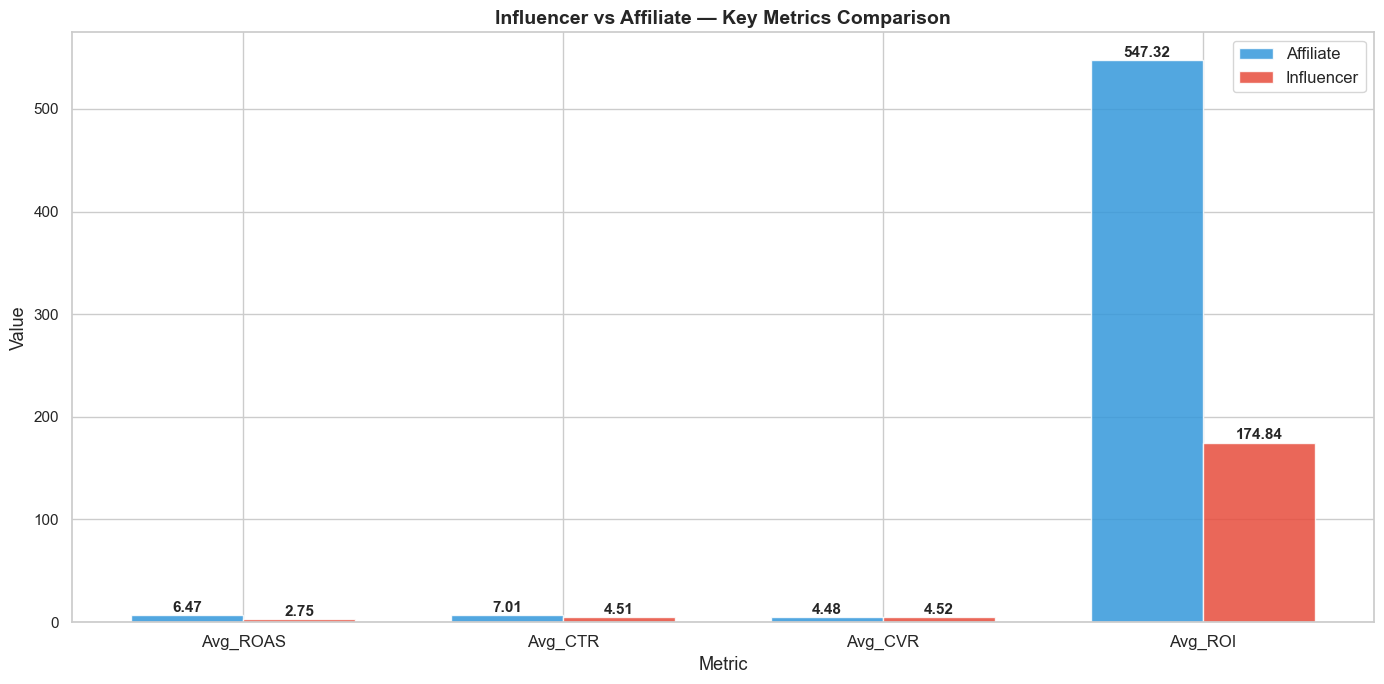

✅ Chart 9 saved!


In [40]:
partner_data = df[df['Channel'].isin(['Influencer', 'Affiliate'])].groupby('Channel').agg(
    Avg_ROAS             = ('ROAS',    'mean'),
    Avg_CTR              = ('CTR',     'mean'),
    Avg_CVR              = ('CVR',     'mean'),
    Avg_ROI              = ('ROI_Pct', 'mean'),
    Total_Revenue        = ('Revenue', 'sum')
).reset_index()


partner_data['Avg_ROAS']    = partner_data['Avg_ROAS'].round(2)
partner_data['Avg_CTR']     = partner_data['Avg_CTR'].round(2)
partner_data['Avg_CVR']     = partner_data['Avg_CVR'].round(2)
partner_data['Avg_ROI']     = partner_data['Avg_ROI'].round(2)
partner_data['Total_Revenue_M'] = (partner_data['Total_Revenue'] / 1e6).round(2)

print("📌 Influencer vs Affiliate Comparison:")
print(partner_data[['Channel', 'Avg_ROAS', 'Avg_CTR', 'Avg_CVR', 'Avg_ROI', 'Total_Revenue_M']])

metrics_cols = ['Avg_ROAS', 'Avg_CTR', 'Avg_CVR', 'Avg_ROI']

melted = pd.melt(
    partner_data,
    id_vars    = 'Channel',
    value_vars = metrics_cols,
    var_name   = 'Metric',
    value_name = 'Value'
)

print("\n📌 Melted Data:")
print(melted)



fig, ax = plt.subplots(figsize=(14, 7))

channels  = melted['Channel'].unique()
metrics   = melted['Metric'].unique()
x         = np.arange(len(metrics))
width     = 0.35
colors    = ['#3498DB', '#E74C3C']

for i, (channel, color) in enumerate(zip(channels, colors)):
    subset = melted[melted['Channel'] == channel]
    bars   = ax.bar(x + i * width, subset['Value'],
                    width=width, color=color,
                    label=channel, alpha=0.85)

    for bar, val in zip(bars, subset['Value']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

ax.set_title('Influencer vs Affiliate — Key Metrics Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Value', fontsize=13)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart9_influencer_vs_affiliate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

### Chart 9 — Insight: Influencer vs Affiliate Comparison

**Key Insights:**
- Affiliate channel outperforms Influencer across every single metric
- Affiliate ROAS is 6.47 vs Influencer ROAS of 2.75 — Affiliate generates more than 2x the return per rupee spent
- The biggest gap is in ROI — Affiliate delivers 547% ROI compared to only 175% for Influencer
- CTR is also higher for Affiliate (7.01%) vs Influencer (4.51%) — Affiliate content drives more clicks
- CVR is almost identical for both (4.48% vs 4.52%) — once a user clicks, conversion rate is similar
- The data clearly shows that Influencer marketing is not delivering value compared to Affiliate partnerships
- Budget should be shifted from Influencer to Affiliate channel for better returns

# Chart 10 — Correlation Heatmap

📌 Correlation Matrix (first 5 cols):
             Impressions  Clicks  Conversions  Spend  Revenue
Impressions         1.00    0.67         0.60   0.96     0.80
Clicks              0.67    1.00         0.90   0.64     0.85
Conversions         0.60    0.90         1.00   0.58     0.77
Spend               0.96    0.64         0.58   1.00     0.84
Revenue             0.80    0.85         0.77   0.84     1.00


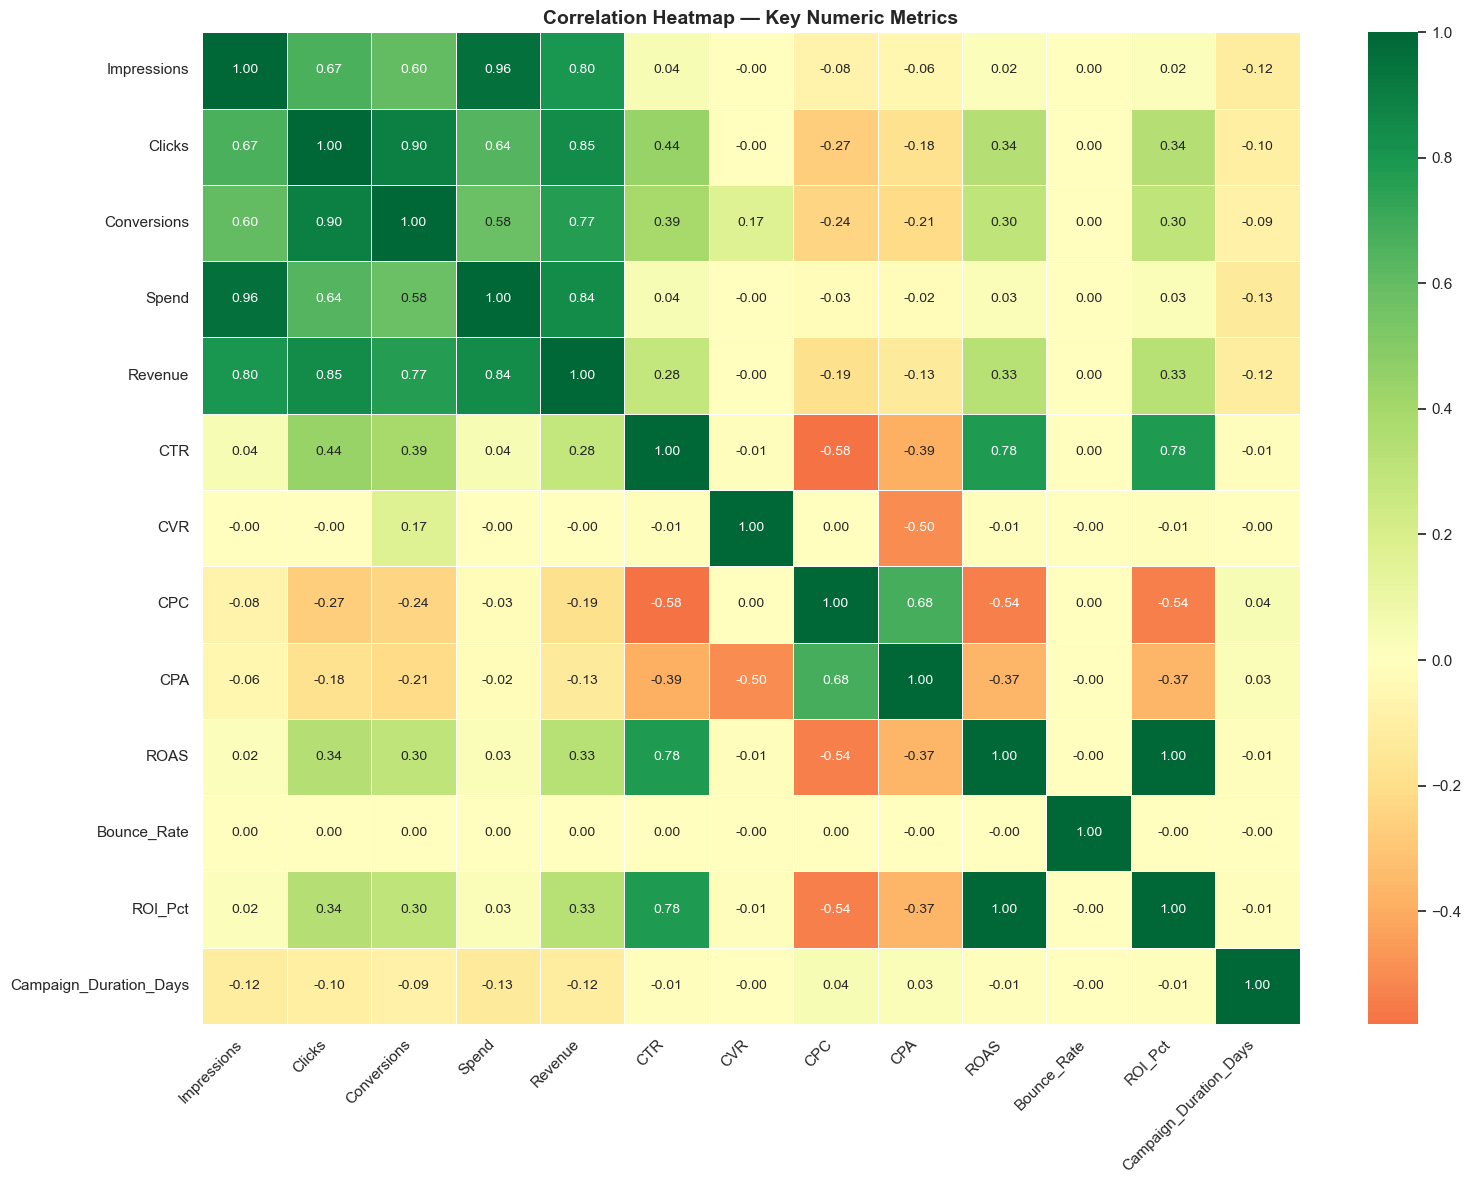

✅ Chart 10 saved!


In [42]:
numeric_cols = ['Impressions', 'Clicks', 'Conversions', 'Spend', 
                'Revenue', 'CTR', 'CVR', 'CPC', 'CPA', 'ROAS', 
                'Bounce_Rate', 'ROI_Pct', 'Campaign_Duration_Days']

corr_matrix = df[numeric_cols].corr().round(2)

print("📌 Correlation Matrix (first 5 cols):")
print(corr_matrix.iloc[:5, :5])

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdYlGn',
    center     = 0,
    linewidths = 0.5,
    linecolor  = 'white',
    annot_kws  = {'size': 10},
    ax         = ax
)

ax.set_title('Correlation Heatmap — Key Numeric Metrics',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('chart10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")


### Chart 10 — Insight: Correlation Heatmap

**Key Insights:**
- Spend and Impressions have the strongest correlation at 0.98 — more budget directly leads to more impressions
- Revenue is strongly correlated with Clicks (0.85) and Spend (0.84) — more investment drives more revenue
- ROAS and ROI_Pct show a perfect correlation of 1.00 — both metrics measure the same thing in different ways
- CTR has a strong positive correlation with ROI (0.75) — campaigns with higher click rates deliver better returns
- CPC and CTR are negatively correlated (-0.55) — higher CTR means lower cost per click, which is ideal
- Bounce Rate shows near-zero correlation with all metrics — it does not impact campaign performance in this dataset
- CVR is largely independent of other metrics — conversion rate is not driven by spend or impressions alone